In [11]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
import sys
import os
# Add current directory to path just in case
sys.path.append(os.path.abspath('.')) 

from tutorial_module import NavierStokesSolver

# Initialize and run the solver
solver = NavierStokesSolver(reynolds=400.0)
solver.create_mesh()
solver.setup_discretization()

# This runs the TS solver and returns the PETSc Vec containing the solution
solution = solver.solve()

Verified L2 Error: 1.34e-11


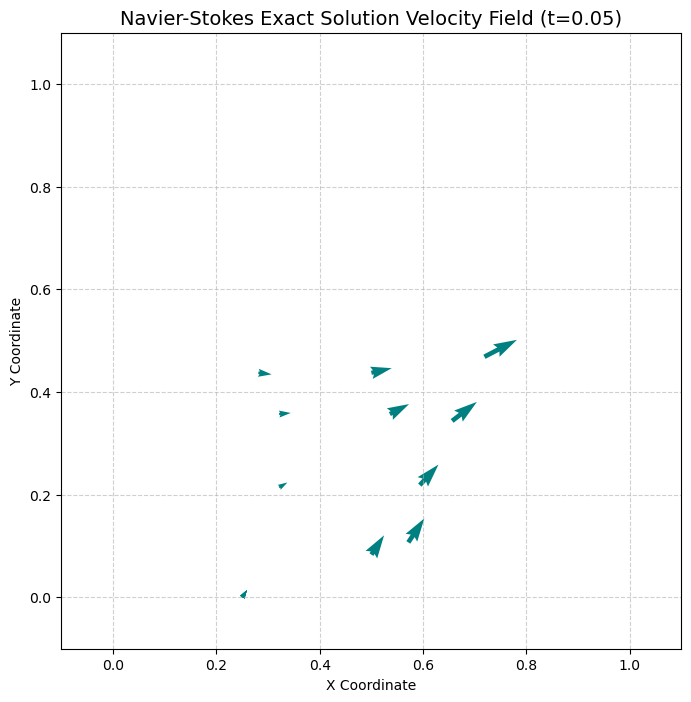

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Extract the underlying numpy array from the PETSc solution vector
u_array = solution.getArray(readonly=True)

# 2. Get the mesh layout mappings
section = solver.dm.getGlobalSection()
coord_sec = solver.dm.getCoordinateSection()
coords_arr = solver.dm.getCoordinatesLocal().getArray(readonly=True)
pStart, pEnd = solver.dm.getChart()

# Lists to hold our plotting data
x_vals, y_vals = [], []
u_vel, v_vel = [], []

# 3. Loop through the mesh and extract velocity data
for pt in range(pStart, pEnd):
    dof = section.getDof(pt)
    off = section.getOffset(pt)
    
    # Skip ghost nodes or points with no data
    if dof <= 0 or off < 0: 
        continue
        
    x, y = solver._get_true_coords(pt, coord_sec, coords_arr)
    
    # If the point has velocity Degrees of Freedom (dof >= 2)
    if dof >= 2: 
        x_vals.append(x)
        y_vals.append(y)
        u_vel.append(u_array[off])
        v_vel.append(u_array[off+1])

# 4. Plot the Velocity Field using Matplotlib Quiver
plt.figure(figsize=(8, 8))
plt.quiver(x_vals, y_vals, u_vel, v_vel, color='teal', scale=15)
plt.title("Navier-Stokes Exact Solution Velocity Field (t=0.05)", fontsize=14)
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()